## Testing Matched Filter + Connected Component Denoising
This notebook demonstrates the effectiveness of a single-size matched filter implementation on an image of a microcrack.

### About Matched Filter
This matched filter approach is derived from a [technique developed to detect cracks on concrete bridges](https://rdcu.be/fhYiN).

The idea is to use a set of templates abstracting ideal crack shapes in different orientations. In our use case, we have 12 kernels rotated at each step by 15 degrees. The 1D Gaussian projected across each template has a scale (sigma) of 44.

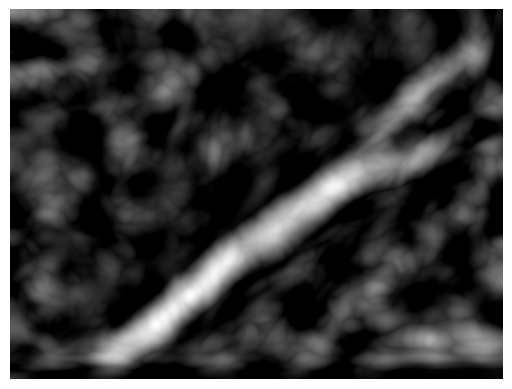

In [37]:
import matched_filter as mf
import matplotlib.pyplot as plt

templates = mf.generate_kernels(sigma=44.0, L=54, angle_step=15)
mask, response = mf.apply_matched_filter_from_path("../images/0098.tif", templates, 0.5)
plt.imshow(response, cmap="gray")
plt.axis('off')
plt.show()

Above shows the **response** of applying the matched filter. Note that because multiple templates are applied, we vote on a pixel by keeping the highest response out of all templates.

This response shows that our generated templates seem to respond best to the crack, but smaller dips in the image still respond when template matching.

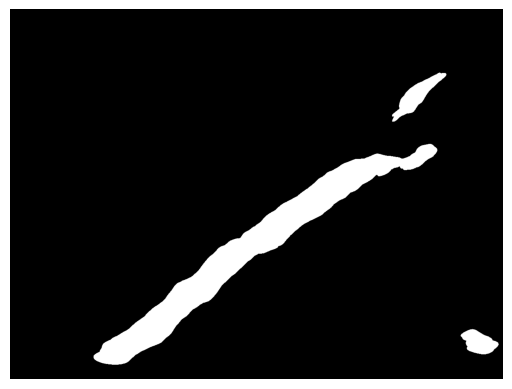

In [38]:
cleaned = mf.ccd(mask, int(mask.size / 500))
plt.imshow(cleaned, cmap='gray')
plt.axis('off')
plt.show()

We can test the effectiveness of the matched filter by calculating the IoU, dice score, and percent error using an annotated image.

In [39]:
import score
import cv2

ground_truth = cv2.imread('../images/annotated/0098.png', cv2.IMREAD_GRAYSCALE)
assert ground_truth is not None
score.iou(cleaned, ground_truth)

0.652206578568194

In [40]:
assert ground_truth is not None
score.precision(cleaned, ground_truth)

0.7876576968491703

In [41]:
assert ground_truth is not None
score.recall(cleaned, ground_truth)

0.7913461538461538

In [42]:
assert ground_truth is not None
score.dice(cleaned, ground_truth)

0.7894976173420126

In [43]:
assert ground_truth is not None
score.percent_err(cleaned, ground_truth)

0.027500813802083333

In [44]:
assert ground_truth is not None
score.percent_success(cleaned, ground_truth)

0.9724991861979166

## Binary Mask Results
**Dice score** usually measures something closer to average-case performance while **IoU** measures something closer to worst-case performance. With the parameters above, we get the following:

- Dice score: `78.95%`
- IoU: `65.22%`

However, both weigh pixel errors inversely proportional to the size of the relevant set rather than weighing them equally. This can lead to large penalties on trivial mistakes with small selected ground truths. Therefore, we have also measured percent error:

- Percent error: `2.75%`

Which is the complement of percent success (`97.25%`).

In [45]:
assert ground_truth is not None
score.soft_iou(response, ground_truth)

0.21560539305210114

In [46]:
assert ground_truth is not None
score.soft_dice(response, ground_truth)

0.03251592853404662

In [47]:
assert ground_truth is not None
score.roc_auc(response, ground_truth)

0.9861723076961342

In [48]:
assert ground_truth is not None
score.pr_auc(response, ground_truth)

0.8710072435518009

## Probabilistic Results
Masking introduces an inherent limitation due to the need to select an appropriate **threshold**. Probabilistic measurements avoid this by scoring the raw response without thresholding; we can thus look at the Receiver-Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) as well as the Precision-Recall (PR) curve and its AUC. Thus, our results come out to be:
- ROC AUC: `98.62%`
- PR AUC: `87.10%`

> Note that PR AUC is a better measurement for performance specifically for our microcrack imaging software because it does not take into account true negatives like ROC AUC. Because there is a "class imbalance" (less positives than negatives or vice versa), ROC AUC will be higher since it factors in these true negatives. PR AUC does not since neither precision nor recall takes into account true negatives.